In [8]:
!pip install pynwb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pynwb import NWBHDF5IO
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 14.7 MB/s eta 0:00:00


In [9]:
# Define test file path
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# Open and read the NWB file
io = NWBHDF5IO(test_file_path, 'r')
nwbfile = io.read()
print(nwbfile)

root pynwb.file.NWBFile at 0x132249567199744
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 56, 620865, tzinfo=tzoffset(None, -14400))]
  identifier: 8d26aa92-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [10]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the test data
test_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)
print(f"Test population matrix shape (Bins x Units): {test_matrix.shape}")
print(f"Total number of recorded neural units in test: {test_matrix.shape[1]}")

Test population matrix shape (Bins x Units): (25465, 40)
Total number of recorded neural units in test: 40


In [11]:
# Convert trials table to a pandas DataFrame
df_trials = nwbfile.trials.to_dataframe()

# Print out the available columns to see what they are named in the test set
print("Available columns in test trials table:")
print(df_trials.columns.tolist())

# Show the first few rows to inspect the data structure
df_trials.head()

Available columns in test trials table:
['start_time', 'stop_time', 'go_time', 'split']


,start_time,stop_time,go_time,split
id,,,,
0,0.0,1.7,1.5,test
1,1.8,3.5,3.3,test
2,3.6,5.3,5.1,test
3,5.4,7.1,6.9,test
4,7.2,8.9,8.7,test


In [12]:
# Convert trials table to a pandas DataFrame
df_trials = nwbfile.trials.to_dataframe()

# Filter for rows where our essential timing cues exist
valid_trials = df_trials[
    (df_trials['start_time'].notna()) & 
    (df_trials['go_time'].notna())
].copy()

# Calculate the target interval duration (ts) dynamically: (go_time - start_time) * 1000 ms
# Then round it to the nearest 10ms to cleanly group the conditions (e.g., 800ms, 900ms)
valid_trials['ts'] = np.round((valid_trials['go_time'] - valid_trials['start_time']) * 100) * 10

# Create a dictionary to group trial sequences by their calculated interval lengths
grouped_by_interval = {}
bin_midpoints = bin_edges[:-1] + (0.02 / 2)

for interval_len, group in valid_trials.groupby('ts'):
    trial_sequences = []
    for _, trial in group.iterrows():
        ready = trial['start_time']  # Using start_time as the Ready cue
        set_ev = trial['go_time']    # Using go_time as the Set cue
        
        # Mask only the time bins that fall within this trial's ready-to-set window
        interval_mask = (bin_midpoints >= ready) & (bin_midpoints <= set_ev)
        trial_data = test_matrix[interval_mask, :]
        
        if len(trial_data) > 0:
            trial_sequences.append(trial_data)
            
    grouped_by_interval[interval_len] = trial_sequences

# Print out a summary to see how many trials we captured for each condition
print("Test Data grouped by dynamically calculated stimulus interval lengths:")
for interval, trials_list in sorted(grouped_by_interval.items()):
    print(f"Interval {int(interval)} ms: {len(trials_list)} trials recorded.")

Test Data grouped by dynamically calculated stimulus interval lengths:
Interval 1500 ms: 283 trials recorded.


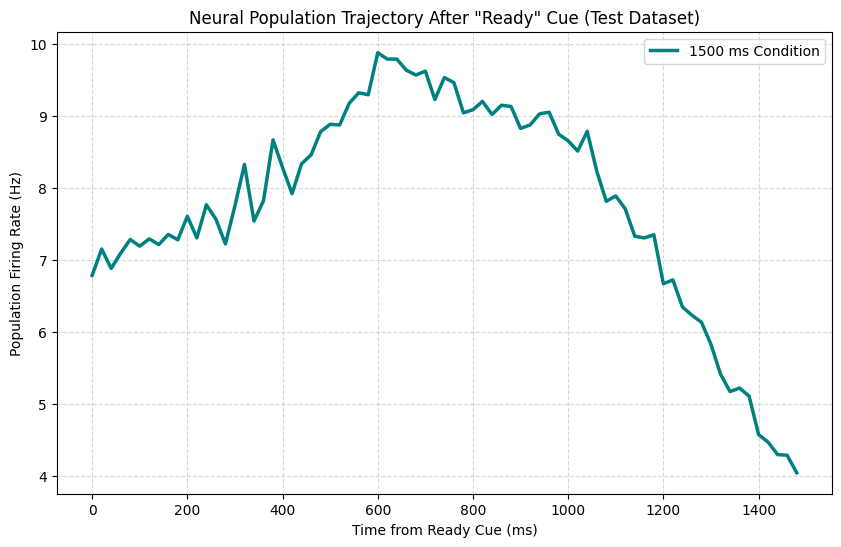

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Since there is only the 1500ms condition, we extract its trials
trials_list = [t for t in grouped_by_interval[1500.0] if len(t) > 0]

# Find the minimum duration length among these trials to average them safely
min_len = min(len(t) for t in trials_list)

# Crop all trials to this minimum length and average across trials (axis=0) and neurons (axis=1)
cropped_trials = [t[:min_len, :] for t in trials_list]
mean_population_profile = np.mean(np.mean(cropped_trials, axis=0), axis=1) / 0.02

# Create a time vector in milliseconds (each bin is 20ms)
time_ms = np.arange(min_len) * 20

# Plot the trajectory
plt.plot(time_ms, mean_population_profile, color='teal', linewidth=2.5, label='1500 ms Condition')

plt.title('Neural Population Trajectory After "Ready" Cue (Test Dataset)', fontsize=12)
plt.xlabel('Time from Ready Cue (ms)', fontsize=10)
plt.ylabel('Population Firing Rate (Hz)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Top time-modulated neuron found in test dataset at index: 21


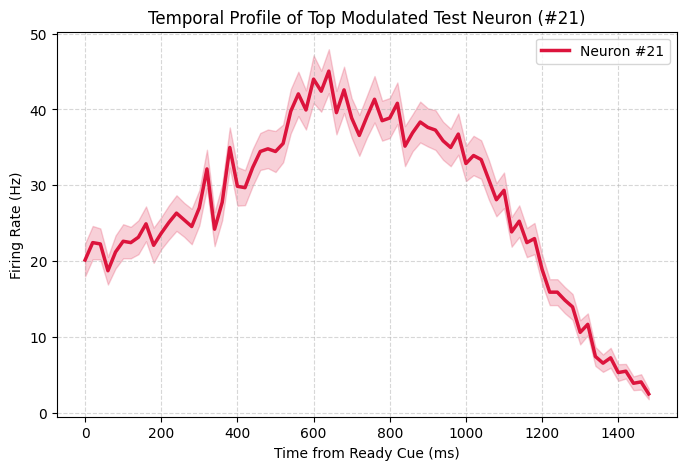

In [14]:
import numpy as np

# We use the pre-cropped trials from the previous step
# cropped_trials shape: (283 trials, min_len steps, 40 neurons)
cropped_trials_matrix = np.array(cropped_trials) / 0.02  # Convert to Hz

# Calculate the mean time-course for each of the 40 neurons across all trials
mean_neuron_profiles = np.mean(cropped_trials_matrix, axis=0)  # Shape: (min_len, 40)

# Find the neuron with the highest variance (the one changing its firing rate the most over time)
neuron_variances = np.var(mean_neuron_profiles, axis=0)
best_neuron_idx = np.argmax(neuron_variances)

print(f"Top time-modulated neuron found in test dataset at index: {best_neuron_idx}")

# Calculate the mean and Standard Error (SEM) over trials for this specific neuron
best_neuron_mean = mean_neuron_profiles[:, best_neuron_idx]
best_neuron_sem = np.std(cropped_trials_matrix[:, :, best_neuron_idx], axis=0) / np.sqrt(len(cropped_trials))

# Plot the tuning curve over time
plt.figure(figsize=(8, 5))
time_ms = np.arange(min_len) * 20

plt.plot(time_ms, best_neuron_mean, color='crimson', linewidth=2.5, label=f'Neuron #{best_neuron_idx}')
plt.fill_between(time_ms, best_neuron_mean - best_neuron_sem, best_neuron_mean + best_neuron_sem, color='crimson', alpha=0.2)

plt.title(f'Temporal Profile of Top Modulated Test Neuron (#{best_neuron_idx})', fontsize=12)
plt.xlabel('Time from Ready Cue (ms)', fontsize=10)
plt.ylabel('Firing Rate (Hz)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

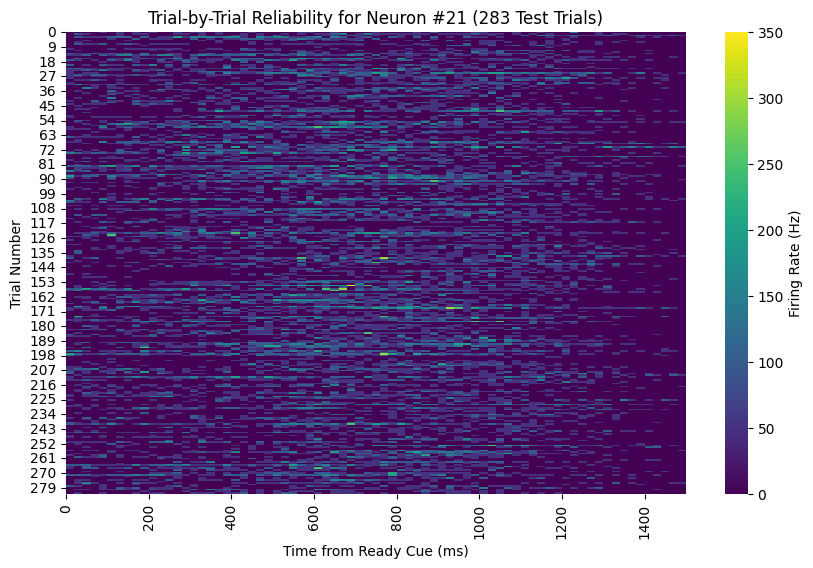

In [15]:
import seaborn as sns

# Extract only Neuron #21's firing rates across all trials and time points
# Shape will be: (283 trials, min_len time steps)
neuron_21_data = cropped_trials_matrix[:, :, 21]

plt.figure(figsize=(10, 6))
# Create the heatmap (Rows = Trials, Columns = Time)
sns.heatmap(neuron_21_data, cmap='viridis', cbar_kws={'label': 'Firing Rate (Hz)'})

# Fix time axis labels to show milliseconds instead of bin indices
time_ticks = np.arange(0, min_len, 10)
plt.xticks(time_ticks, time_ticks * 20)

plt.title('Trial-by-Trial Reliability for Neuron #21 (283 Test Trials)', fontsize=12)
plt.xlabel('Time from Ready Cue (ms)', fontsize=10)
plt.ylabel('Trial Number', fontsize=10)
plt.show()

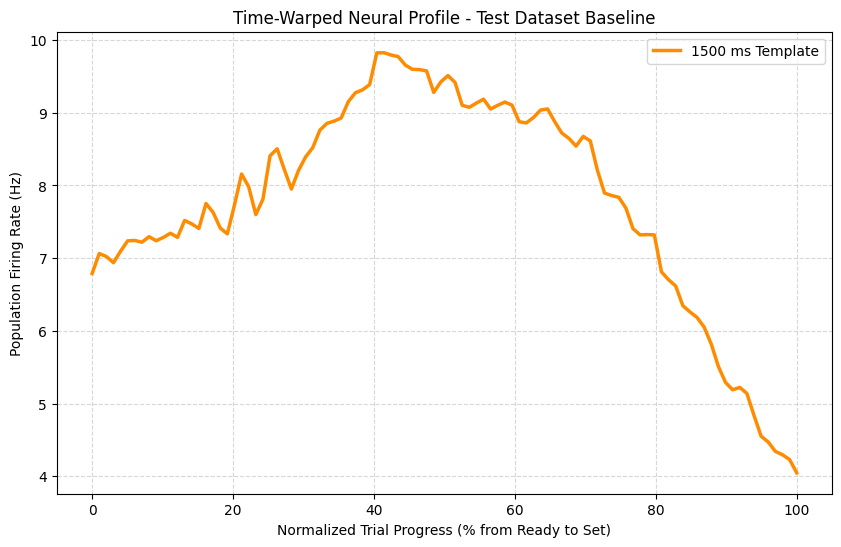

In [16]:
from scipy.interpolate import interp1d

plt.figure(figsize=(10, 6))

# Define a standard normalized time vector (0% to 100% of the interval)
normalized_time = np.linspace(0, 100, 100)

# Extract trials list for the 1500 ms condition
trials_list = [t for t in grouped_by_interval[1500.0] if len(t) > 0]
min_len = min(len(t) for t in trials_list)

# 1. Get the average population trajectory across trials (Time x Units)
cropped_trials = [t[:min_len, :] for t in trials_list]
mean_population_profile = np.mean(np.mean(cropped_trials, axis=0), axis=1) / 0.02

# 2. Create the original time steps for this specific interval
original_time_steps = np.arange(min_len)
# Convert to percentage of total trial length (0 to 100)
original_percentage = (original_time_steps / (min_len - 1)) * 100

# 3. Interpolate (stretch/warp) the data onto our standard 0-100% grid
warping_function = interp1d(original_percentage, mean_population_profile, kind='linear')
warped_trajectory = warping_function(normalized_time)

# Plot the time-warped line
plt.plot(normalized_time, warped_trajectory, color='darkorange', linewidth=2.5, label='1500 ms Template')

plt.title('Time-Warped Neural Profile - Test Dataset Baseline', fontsize=12)
plt.xlabel('Normalized Trial Progress (% from Ready to Set)', fontsize=10)
plt.ylabel('Population Firing Rate (Hz)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

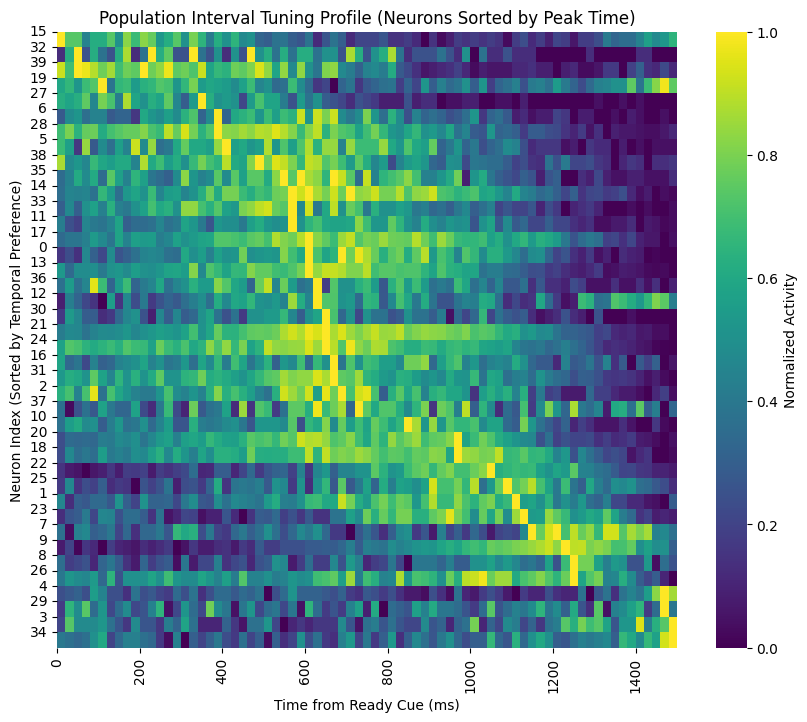

In [17]:
# 1. Normalize each neuron's mean profile between 0 and 1 to compare tuning peaks
normalized_profiles = np.zeros_like(mean_neuron_profiles)
for unit in range(mean_neuron_profiles.shape[1]):
    min_val = np.min(mean_neuron_profiles[:, unit])
    max_val = np.max(mean_neuron_profiles[:, unit])
    if max_val > min_val:
        normalized_profiles[:, unit] = (mean_neuron_profiles[:, unit] - min_val) / (max_val - min_val)
    else:
        normalized_profiles[:, unit] = 0

# 2. Find the exact time bin where each neuron reaches its maximum firing rate
peak_bins = np.argmax(normalized_profiles, axis=0)

# 3. Sort the neurons based on when they peak (from 0 ms to 1500 ms)
sorted_neuron_indices = np.argsort(peak_bins)
sorted_profiles = normalized_profiles[:, sorted_neuron_indices].T

# 4. Plot the population temporal tuning tiling matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sorted_profiles, cmap='viridis', cbar_kws={'label': 'Normalized Activity'})

# Adjust the axes labels to reflect actual time mapping
time_ticks = np.arange(0, min_len, 10)
plt.xticks(time_ticks, time_ticks * 20)
plt.yticks(np.arange(len(sorted_neuron_indices)), sorted_neuron_indices)

plt.title('Population Interval Tuning Profile (Neurons Sorted by Peak Time)', fontsize=12)
plt.xlabel('Time from Ready Cue (ms)', fontsize=10)
plt.ylabel('Neuron Index (Sorted by Temporal Preference)', fontsize=10)
plt.show()

In [20]:
# Check if we can pull the Set-to-Go data for the 1500ms condition
sample_trial = valid_trials.iloc[0]
s_idx = int(sample_trial['go_time'] / 0.02)
e_idx = int(sample_trial['stop_time'] / 0.02)

print(f"Sample indices: {s_idx} to {e_idx}")
print(f"Slice shape: {test_matrix[s_idx:e_idx, :].shape}")

Sample indices: 75 to 85
Slice shape: (10, 40)


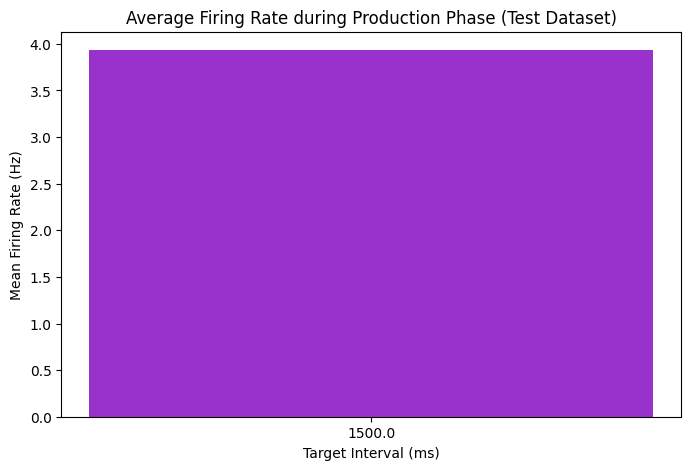

In [21]:
# Calculate mean firing rate for the production phase (Test Data)
results = []
# We use the 'valid_trials' that you defined in Cell #11
for interval_len, group in valid_trials.groupby('ts'):
    rates = []
    for _, trial in group.iterrows():
        s_idx = int(trial['go_time'] / 0.02)
        e_idx = int(trial['stop_time'] / 0.02)
        
        # Ensure indices are valid and window is not empty
        if s_idx < e_idx and e_idx <= test_matrix.shape[0]:
            # Use test_matrix here, not train_matrix
            trial_mean = np.mean(test_matrix[s_idx:e_idx, :] / 0.02)
            rates.append(trial_mean)
            
    if rates:
        results.append({'Interval': interval_len, 'Mean Rate': np.mean(rates)})

df_results = pd.DataFrame(results)

# Plot as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(df_results['Interval'].astype(str), df_results['Mean Rate'], color='darkorchid')
plt.title('Average Firing Rate during Production Phase (Test Dataset)')
plt.xlabel('Target Interval (ms)')
plt.ylabel('Mean Firing Rate (Hz)')
plt.show()

In [23]:
from scipy import stats

# 1. Collect firing rates for the Set-to-Go phase using test data
all_interval_groups = []

# Filter for the 1500ms condition (the only one in your test set)
group_rates = []
for _, trial in valid_trials[valid_trials['ts'] == 1500.0].iterrows():
    s_idx = int(trial['go_time'] / 0.02)
    e_idx = int(trial['stop_time'] / 0.02)
    
    # Ensure indices exist in test_matrix
    if s_idx < e_idx and e_idx <= test_matrix.shape[0]:
        # USE test_matrix HERE
        trial_mean = np.mean(test_matrix[s_idx:e_idx, :] / 0.02)
        group_rates.append(trial_mean)

if group_rates:
    all_interval_groups.append(group_rates)
    print(f"Set-to-Go Mean Firing Rate (1500ms): {np.mean(group_rates):.2f} Hz")
    print(f"Standard Deviation: {np.std(group_rates):.2f}")

Set-to-Go Mean Firing Rate (1500ms): 3.93 Hz
Standard Deviation: 1.08
